<a href="https://colab.research.google.com/github/nanaaries313/Portfolio/blob/main/Evaluation_and_RF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Week 11: Ensembles: Random Forest**

Load all the packages we are going to use


In [6]:
pkgs <- c("rpart", "rpart.plot", "caret", "ggplot2", "randomForest", "ranger")
to_install <- pkgs[!pkgs %in% rownames(installed.packages())]
if (length(to_install) > 0) install.packages(to_install)

In [7]:
library(rpart)
library(rpart.plot)
library(caret)
library(ggplot2)
library(randomForest)
library(ranger)


##**Random Forest for Iris Data**

In [8]:
set.seed(3)
train = sample(1:150,size = 100, replace =FALSE)

*This select 100 observations for a training dataset from a larger dataset, such as iris dataset which has 150 observations*

Simple CART tree

In [9]:
tree = rpart(Species~.,
             data = iris[train,])
CM = table(predict(tree,iris[-train,],type="class"),
           iris[-train,]$Species) #testing error
CM
1-(CM[1,1]+CM[2,2]+CM[3,3])/sum(CM) #error rate

            
             setosa versicolor virginica
  setosa         17          0         0
  versicolor      0         17         2
  virginica       0          0        14

[1] 0.04

Maybe we can improve with random forest?

In [10]:
rf.iris = randomForest(iris[train,1:4],
                       iris[train,]$Species)

*randomForest(predictor variables, target variable)

We used the default parameters (you should experiment with those)

In [11]:
rf.iris$ntree #numbers of tree
rf.iris$mtry

[1] 500

[1] 2

mtry = number of variables randomly sampled at each split. The default value for classification is sqrt(total variables). It could be all the variables in the dataset

There is a built-in confusion matrix

In [12]:
rf.iris$confusion #out of bag error
CM = rf.iris$confusion
1-(CM[1,1]+CM[2,2]+CM[3,3])/sum(CM)

,setosa,versicolor,virginica,class.error
setosa,33,0,0,0.00000000
versicolor,0,30,3,0.09090909
virginica,0,4,30,0.11764706


[1] 0.07193554

Or we can estimate it ourselves using the test data

In [13]:
CM = table(predict(rf.iris,iris[-train,],
                   type="class"),
           iris[-train,]$Species)
CM
1-(CM[1,1]+CM[2,2]+CM[3,3])/sum(CM)

            
             setosa versicolor virginica
  setosa         17          0         0
  versicolor      0         17         2
  virginica       0          0        14

[1] 0.04

Why are they different? since they are different error estimate types (out of bag vs testing). I shouldn't compare them directly.We should apply RF model on test to compare them.

It looks like the random forest is doing nothing. The problem is simple so both DT and RF doing well.

The plot function when applied to a random forest object plots the error rates as a function of the number of trees

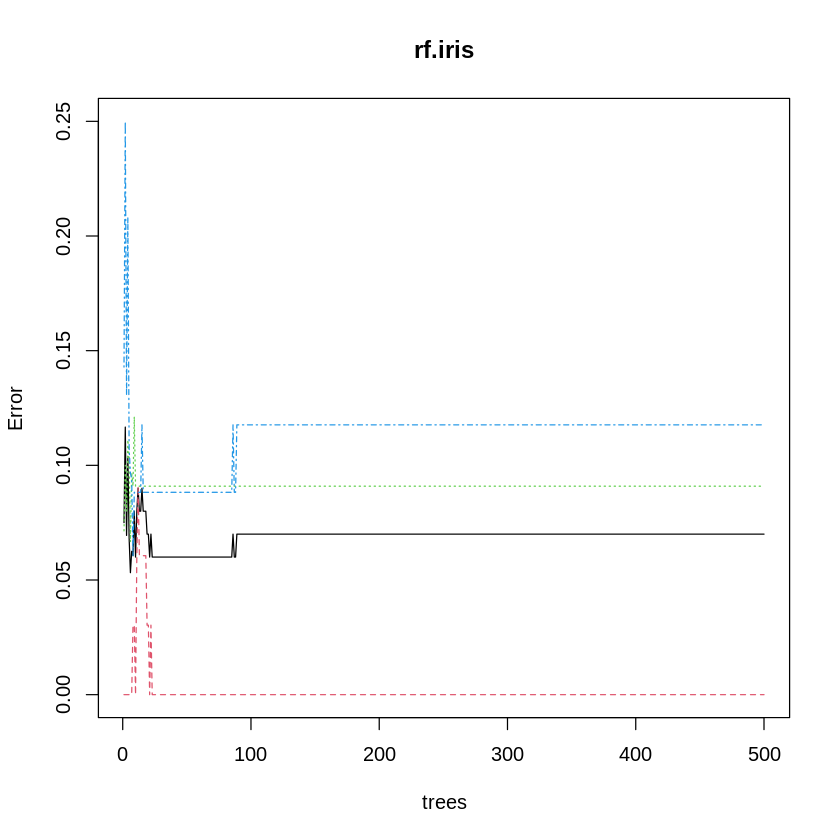

In [14]:
plot(rf.iris) # Not sure how useful you'll find this

Random forest gives us useful information about the importance of predictor variables (this is the basis for Boruta)

In [15]:
rf.iris$importance

,MeanDecreaseGini
Sepal.Length,6.421524
Sepal.Width,2.268045
Petal.Length,27.819482
Petal.Width,29.413722


And there is a function to plot the importance (not great)

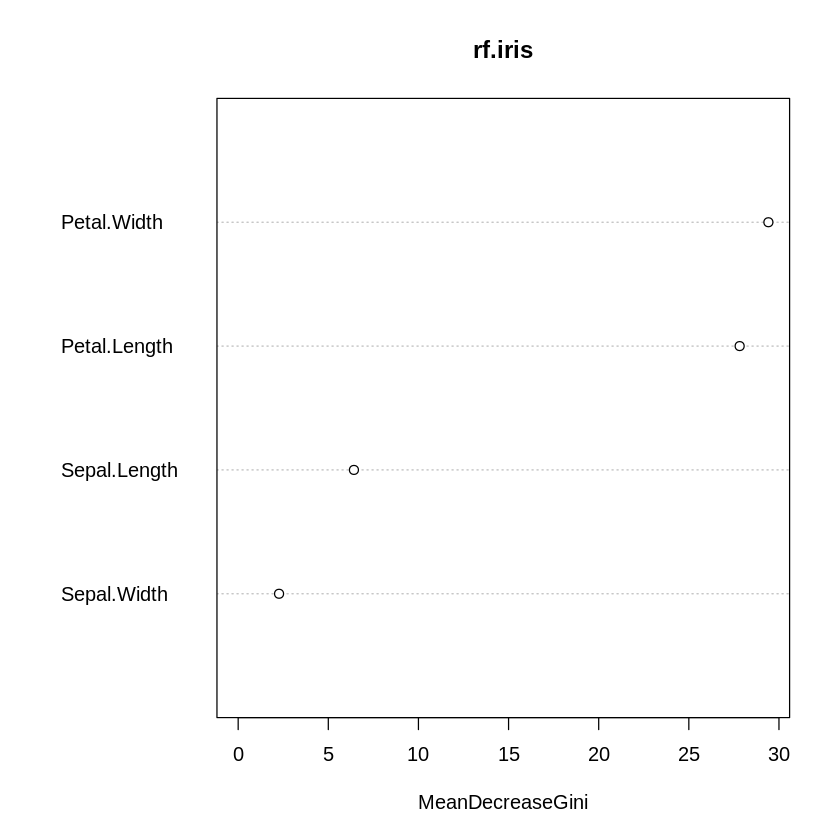

In [16]:
varImpPlot(rf.iris)

Is this consistent with what we knew about the iris data?

You can get the nitty-gritty of how the trees voted for each classification

In [17]:
View(rf.iris$votes)

,setosa,versicolor,virginica
5,1.000000000,0.000000000,0.000000000
140,0.000000000,0.000000000,1.000000000
36,1.000000000,0.000000000,0.000000000
107,0.000000000,0.959770115,0.040229885
136,0.000000000,0.000000000,1.000000000
20,1.000000000,0.000000000,0.000000000
74,0.000000000,0.984536082,0.015463918
48,1.000000000,0.000000000,0.000000000
104,0.000000000,0.000000000,1.000000000
146,0.000000000,0.016949153,0.983050847


And more ... as always explore

##**Random Forest for Glass Data**

Read in the glass data

In [18]:
glass = read.csv("glass.csv",
                 stringsAsFactors = TRUE)

View(glass)

RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1.51793,12.79,3.50,1.12,73.03,0.64,8.77,0.00,0.00,'build wind float'
1.51643,12.16,3.52,1.35,72.89,0.57,8.53,0.00,0.00,'vehic wind float'
1.51793,13.21,3.48,1.41,72.64,0.59,8.43,0.00,0.00,'build wind float'
1.51299,14.40,1.74,1.54,74.55,0.00,7.59,0.00,0.00,tableware
1.53393,12.30,0.00,1.00,70.16,0.12,16.19,0.00,0.24,'build wind non-float'
1.51655,12.75,2.85,1.44,73.27,0.57,8.79,0.11,0.22,'build wind non-float'
1.51779,13.64,3.65,0.65,73.00,0.06,8.93,0.00,0.00,'vehic wind float'
1.51837,13.14,2.84,1.28,72.85,0.55,9.07,0.00,0.00,'build wind float'
1.51545,14.14,0.00,2.68,73.39,0.08,9.07,0.61,0.05,headlamps


Create a training/test sample

In [19]:
m = length(glass$Type) # Number of data points
set.seed(1)
train = sample(1:m,
               size = as.integer(m*0.8), #80% for training
               replace =FALSE)

Simple tree as a benchmark

In [20]:
tree = rpart(Type~.,
             data = glass[train,],
             control=rpart.control(cp = 0.001))
CM=table(glass[-train,]$Type,predict(tree,glass[-train,],type="class"))
error=1-(sum(diag(CM)))/sum(CM)
error

[1] 0.4651163

cp is from the previous result. 0.001 was the best cp

This is clearly a more difficult classification problem with a high error rate. Hopefully, ensembles can help!


In [21]:
rf.glass = randomForest(glass[train,1:9],
                        glass[train,]$Type,
                        ntree = 500)
rf.glass$ntree
rf.glass$mtry
rf.glass$confusion

[1] 500

[1] 3

,'build wind float','build wind non-float','vehic wind float',containers,headlamps,tableware,class.error
'build wind float',48,7,2,0,0,0,0.15789474
'build wind non-float',8,44,2,2,0,2,0.24137931
'vehic wind float',7,2,6,0,0,0,0.60000000
containers,0,1,0,11,0,0,0.08333333
headlamps,0,0,0,1,21,0,0.04545455
tableware,0,3,0,0,0,4,0.42857143


For a fair comparison, lets estimate the error on the test data:

In [22]:
CM = table(predict(rf.glass,glass[-train,],type="class"),
           glass[-train,]$Type)
CM
1-(CM[1,1]+CM[2,2]+CM[3,3]+
     CM[4,4]+CM[5,5]+CM[6,6])/sum(CM)

                        
                         'build wind float' 'build wind non-float'
  'build wind float'                     10                      2
  'build wind non-float'                  2                     12
  'vehic wind float'                      1                      1
  containers                              0                      2
  headlamps                               0                      1
  tableware                               0                      0
                        
                         'vehic wind float' containers headlamps tableware
  'build wind float'                      0          0         1         0
  'build wind non-float'                  0          0         1         0
  'vehic wind float'                      2          0         0         0
  containers                              0          0         0         0
  headlamps                               0          1         5         0
  tableware                    

[1] 0.2790698

Let's try tuning the RF. Can we get better results with more trees? Will we get worse results with fewer trees?

In [23]:
CM = rf.glass$confusion
1-(CM[1,1]+CM[2,2]+CM[3,3]+
     CM[4,4]+CM[5,5]+CM[6,6])/sum(CM)

[1] 0.2234434

 Conclusion?
Any elephants in the room?
We use testing data to estimate error. 0 bias but high variance.

Let's do a systematic experiment




In [24]:
error = matrix(nrow=10,
               ncol=2)
for(i in 1:10){
  set.seed(i)
  train = sample(1:m,
                 size = as.integer(m*0.8),
                 replace =FALSE)
  rf.glass = randomForest(glass[train,1:9],
                          glass[train,]$Type,
                          ntree=500)
  CM1 = rf.glass$confusion
  CM2 = table(predict(rf.glass,glass[-train,],type="class"),
             glass[-train,]$Type)
  error[i,1] = 1-sum(diag(CM1))/sum(CM1)
  error[i,2] = 1-sum(diag(CM2))/sum(CM2)
}
colMeans(error)

error

[1] 0.2341097 0.2395349

0.2356981,0.27906977
0.2226272,0.25581395
0.2373955,0.34883721
0.2354896,0.09302326
0.2360789,0.18604651
0.2241920,0.32558140
0.2417456,0.23255814
0.2594265,0.18604651
0.2532327,0.23255814
0.1952104,0.25581395


Higher variance in testing error and more conservative in out of bag error

What is an appropriate way to use our data?

How many models did we build? Which model do we use?


Alternative: use the ranger package

In [25]:
ranger.glass = ranger(Type~.,data=glass[train,])